In [57]:
import warnings
from sklearn import metrics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rc('font', size=14)
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import scale
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn import metrics
import statsmodels.stats.api as sms
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import zscore

In [5]:
data = pd.read_csv('credit.csv')

In [6]:
df = data.copy()

In [7]:
data.head()

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_duration,percent_of_income,years_at_residence,age,other_credit,housing,existing_loans_count,job,dependents,phone,default
0,< 0 DM,6,critical,furniture/appliances,1169,unknown,> 7 years,4,4,67,none,own,2,skilled,1,yes,no
1,1 - 200 DM,48,good,furniture/appliances,5951,< 100 DM,1 - 4 years,2,2,22,none,own,1,skilled,1,no,yes
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 years,2,3,49,none,own,1,unskilled,2,no,no
3,< 0 DM,42,good,furniture/appliances,7882,< 100 DM,4 - 7 years,2,4,45,none,other,1,skilled,2,no,no
4,< 0 DM,24,poor,car,4870,< 100 DM,1 - 4 years,3,4,53,none,other,2,skilled,2,no,yes


In [8]:
data.isnull().sum()

checking_balance        0
months_loan_duration    0
credit_history          0
purpose                 0
amount                  0
savings_balance         0
employment_duration     0
percent_of_income       0
years_at_residence      0
age                     0
other_credit            0
housing                 0
existing_loans_count    0
job                     0
dependents              0
phone                   0
default                 0
dtype: int64

In [9]:
data.isna().sum()

checking_balance        0
months_loan_duration    0
credit_history          0
purpose                 0
amount                  0
savings_balance         0
employment_duration     0
percent_of_income       0
years_at_residence      0
age                     0
other_credit            0
housing                 0
existing_loans_count    0
job                     0
dependents              0
phone                   0
default                 0
dtype: int64

In [10]:
data.isin([0]).sum()

checking_balance        0
months_loan_duration    0
credit_history          0
purpose                 0
amount                  0
savings_balance         0
employment_duration     0
percent_of_income       0
years_at_residence      0
age                     0
other_credit            0
housing                 0
existing_loans_count    0
job                     0
dependents              0
phone                   0
default                 0
dtype: int64

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   checking_balance      1000 non-null   object
 1   months_loan_duration  1000 non-null   int64 
 2   credit_history        1000 non-null   object
 3   purpose               1000 non-null   object
 4   amount                1000 non-null   int64 
 5   savings_balance       1000 non-null   object
 6   employment_duration   1000 non-null   object
 7   percent_of_income     1000 non-null   int64 
 8   years_at_residence    1000 non-null   int64 
 9   age                   1000 non-null   int64 
 10  other_credit          1000 non-null   object
 11  housing               1000 non-null   object
 12  existing_loans_count  1000 non-null   int64 
 13  job                   1000 non-null   object
 14  dependents            1000 non-null   int64 
 15  phone                 1000 non-null   o

### Bivariate analysis

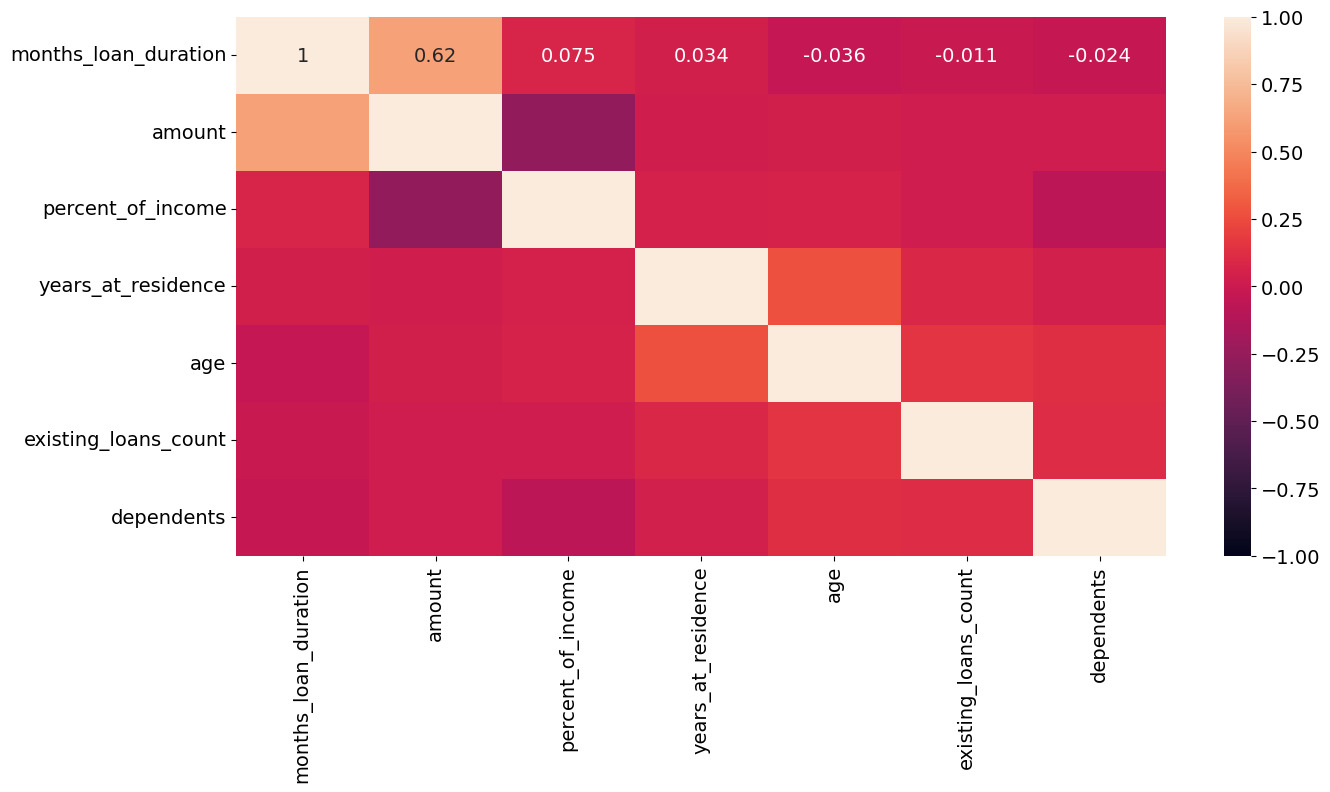

In [12]:
num_col = data.select_dtypes(include='number')
plt.figure(figsize=(15,7))
sns.heatmap(num_col.corr(), vmin=-1, vmax=1, annot=True)
plt.show();

C:\Users\Hrishikesh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to 

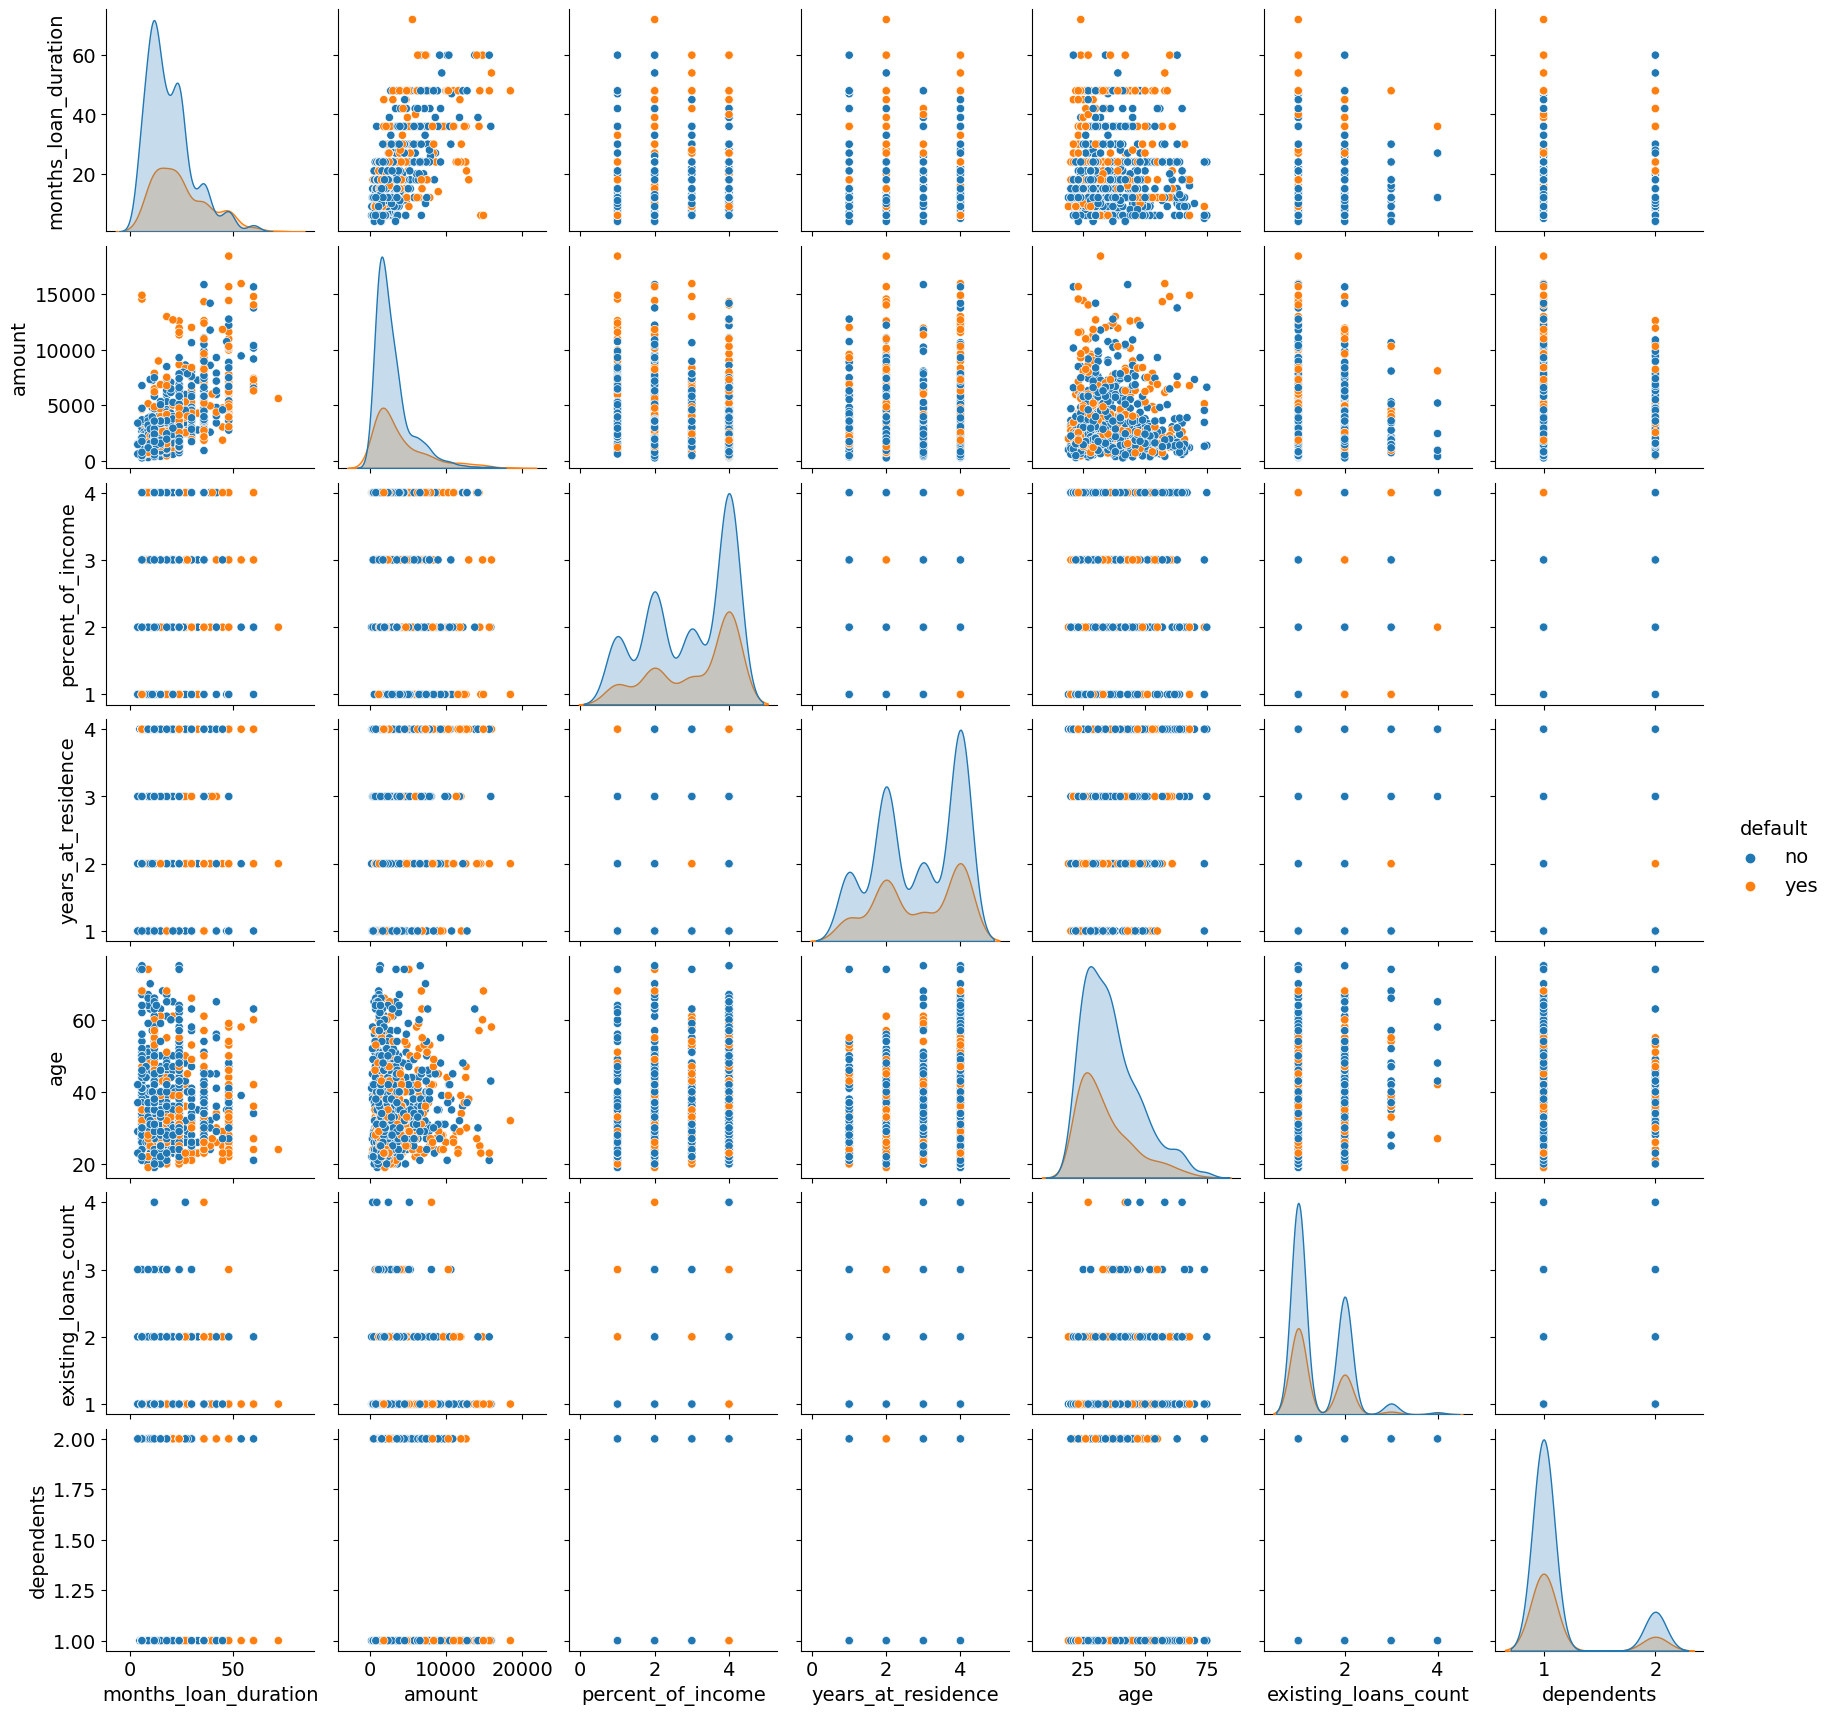

In [13]:
sns.pairplot(data, hue='default')
plt.show();

In [14]:
round(data['default'].value_counts(1),3)*100

default
no     70.0
yes    30.0
Name: proportion, dtype: float64

In [15]:
x = data.drop(['default'], axis=1)
y = data['default']
x = add_constant(x)
x = pd.get_dummies(x, drop_first=True).astype(int)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 1, stratify = y)

In [16]:
y_train = y_train.map({'yes': 1, 'no': 0})

In [17]:
y_test = y_test.map({'yes': 1, 'no': 0})

In [18]:
lg = sm.Logit(y_train, x_train).fit()

Optimization terminated successfully.
         Current function value: 0.477010
         Iterations 7


In [19]:
print(lg.summary())

                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                  700
Model:                          Logit   Df Residuals:                      664
Method:                           MLE   Df Model:                           35
Date:                Tue, 22 Apr 2025   Pseudo R-squ.:                  0.2191
Time:                        11:39:27   Log-Likelihood:                -333.91
converged:                       True   LL-Null:                       -427.61
Covariance Type:            nonrobust   LLR p-value:                 9.800e-23
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                              -3.3474      1.129     -2.966      0.003      -5.559      -1.135
months_loan_duration                0.0269      0.011      2.463    

In [20]:
pred_train = np.round(lg.predict(x_train)>0.5)

In [21]:
confusion_matrix(y_train, pred_train)

array([[439,  51],
       [112,  98]], dtype=int64)

In [22]:
accuracy_score(y_train, pred_train)

0.7671428571428571

In [23]:
vif_series = pd.Series([variance_inflation_factor(x_train.values, i) for i in range(x_train.shape[1])],
                       index=x_train.columns,
                       dtype=float)
vif_series

const                              133.743967
months_loan_duration                 2.044886
amount                               2.483381
percent_of_income                    1.364809
years_at_residence                   1.333982
age                                  1.433046
existing_loans_count                 1.798798
dependents                           1.120428
checking_balance_< 0 DM              1.651784
checking_balance_> 200 DM            1.258681
checking_balance_unknown             1.662607
credit_history_good                  2.276183
credit_history_perfect               1.219296
credit_history_poor                  1.381345
credit_history_very good             1.416936
purpose_car                          3.716879
purpose_car0                         1.236294
purpose_education                    1.681852
purpose_furniture/appliances         3.858595
purpose_renovations                  1.314291
savings_balance_500 - 1000 DM        1.634105
savings_balance_< 100 DM          

In [24]:
x_train1 = x_train.drop(columns =['job_unskilled',
                        'job_unemployed',
                        'job_skilled',
                        'other_credit_store',
                        'housing_own',
                        'employment_duration_> 7 years',
                        'employment_duration_4 - 7 years',
                        'savings_balance_< 100 DM',
                        'savings_balance_500 - 1000 DM',
                        'purpose_renovations',
                        'purpose_furniture/appliances',
                        'purpose_car0',
                        'purpose_car',
                        'dependents',
                        'years_at_residence']
                        ,axis=1)

In [25]:
lg1 = sm.Logit(y_train, x_train1.astype(float)).fit()

Optimization terminated successfully.
         Current function value: 0.481531
         Iterations 7


In [26]:
pred_train1 = np.round(lg1.predict(x_train1))

In [27]:
accuracy_score(y_train, pred_train1)

0.7628571428571429

In [28]:
print(lg1.summary())

                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                  700
Model:                          Logit   Df Residuals:                      679
Method:                           MLE   Df Model:                           20
Date:                Tue, 22 Apr 2025   Pseudo R-squ.:                  0.2117
Time:                        11:39:27   Log-Likelihood:                -337.07
converged:                       True   LL-Null:                       -427.61
Covariance Type:            nonrobust   LLR p-value:                 6.002e-28
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -2.8061      0.761     -3.688      0.000      -4.297      -1.315
months_loan_duration               0.0253      0.011      2.395      0.

In [29]:
x_train2 = x_train1.drop(columns=['age','existing_loans_count','checking_balance_> 200 DM','employment_duration_unemployed','purpose_education'], axis=1)

In [30]:
lg2 = sm.Logit(y_train, x_train2.astype(float)).fit()

Optimization terminated successfully.
         Current function value: 0.488740
         Iterations 7


In [31]:
pred_train2 = np.round(lg2.predict(x_train2))

In [32]:
accuracy_score(y_train, pred_train2)

0.7514285714285714

In [33]:
print(lg2.summary())

                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                  700
Model:                          Logit   Df Residuals:                      684
Method:                           MLE   Df Model:                           15
Date:                Tue, 22 Apr 2025   Pseudo R-squ.:                  0.1999
Time:                        11:39:28   Log-Likelihood:                -342.12
converged:                       True   LL-Null:                       -427.61
Covariance Type:            nonrobust   LLR p-value:                 1.558e-28
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -2.6239      0.474     -5.538      0.000      -3.553      -1.695
months_loan_duration             0.0225      0.010      2.181      0.029     

In [34]:
odds = np.exp(lg2.params)
round(pd.DataFrame(odds, x_train2.columns, columns=['odds']).T,2)

,const,months_loan_duration,amount,percent_of_income,checking_balance_< 0 DM,checking_balance_unknown,credit_history_good,credit_history_perfect,credit_history_poor,credit_history_very good,savings_balance_> 1000 DM,savings_balance_unknown,employment_duration_< 1 year,other_credit_none,housing_rent,phone_yes
odds,0.07,1.02,1.0,1.43,1.62,0.34,1.88,6.51,2.18,3.35,0.27,0.46,1.86,0.51,1.7,0.65


In [35]:
perc_change_odds = (np.exp(lg2.params)-1)*100
pd.DataFrame(perc_change_odds, x_train2.columns, columns=['change_odds%']).T

,const,months_loan_duration,amount,percent_of_income,checking_balance_< 0 DM,checking_balance_unknown,credit_history_good,credit_history_perfect,credit_history_poor,credit_history_very good,savings_balance_> 1000 DM,savings_balance_unknown,employment_duration_< 1 year,other_credit_none,housing_rent,phone_yes
change_odds%,-92.748378,2.280109,0.013757,43.210058,62.063706,-65.726657,87.521461,550.657662,118.449484,235.436256,-72.646495,-54.362678,86.241269,-49.011524,69.951392,-34.696433


### Final Model Performance

In [36]:
confusion_matrix(y_train, pred_train2)

array([[436,  54],
       [120,  90]], dtype=int64)

In [37]:
accuracy_score(y_train, pred_train2)

0.7514285714285714

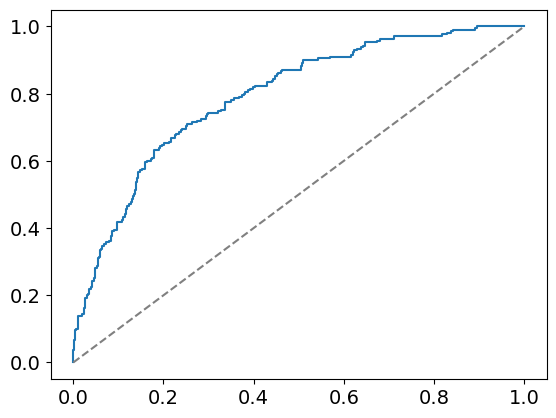

In [38]:
fpr,tpr,_ = roc_curve(y_train, lg2.predict(x_train2))
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],linestyle='--',color='grey')
plt.show();

In [39]:
auc_score = roc_auc_score(y_train, lg2.predict(x_train2))
auc_score

0.792555879494655

### Final Prediction of Test Data

In [40]:
x_test = x_test.drop(columns=['job_unskilled',
                      'job_unemployed',
                      'job_skilled',
                      'other_credit_store',
                      'housing_own',
                      'employment_duration_> 7 years',
                      'employment_duration_4 - 7 years',
                      'savings_balance_< 100 DM',
                      'savings_balance_500 - 1000 DM',
                      'purpose_renovations',
                      'purpose_furniture/appliances',
                      'purpose_car0',
                      'purpose_car',
                      'dependents',
                      'years_at_residence',
                      'age',
                      'existing_loans_count',
                      'checking_balance_> 200 DM',
                      'employment_duration_unemployed',
                      'purpose_education'],axis=1)

In [41]:
pred_test = np.round(lg2.predict(x_test)>0.5)

In [42]:
accuracy_score(y_test, pred_test)

0.77

In [43]:
accuracy_score(y_train, pred_train2)

0.7514285714285714

### Gaussian NB

In [44]:
df.head()

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_duration,percent_of_income,years_at_residence,age,other_credit,housing,existing_loans_count,job,dependents,phone,default
0,< 0 DM,6,critical,furniture/appliances,1169,unknown,> 7 years,4,4,67,none,own,2,skilled,1,yes,no
1,1 - 200 DM,48,good,furniture/appliances,5951,< 100 DM,1 - 4 years,2,2,22,none,own,1,skilled,1,no,yes
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 years,2,3,49,none,own,1,unskilled,2,no,no
3,< 0 DM,42,good,furniture/appliances,7882,< 100 DM,4 - 7 years,2,4,45,none,other,1,skilled,2,no,no
4,< 0 DM,24,poor,car,4870,< 100 DM,1 - 4 years,3,4,53,none,other,2,skilled,2,no,yes


In [45]:
df['default'].value_counts(1)*100

default
no     70.0
yes    30.0
Name: proportion, dtype: float64

In [47]:
x_nb = df.drop(['default'],axis=1)
y_nb = df['default']
x_nb = pd.get_dummies(x_nb, drop_first=True).astype(int)
x_train, x_test, y_train, y_test = train_test_split(x_nb, y_nb, test_size = 0.3, random_state = 1, stratify = y)

In [49]:
model = GaussianNB()
model.fit(x_train, y_train.ravel())

GaussianNB()

In [50]:
pred_train = model.predict(x_train)

In [51]:
print(classification_report(y_train, pred_train))

              precision    recall  f1-score   support

          no       0.81      0.81      0.81       490
         yes       0.57      0.57      0.57       210

    accuracy                           0.74       700
   macro avg       0.69      0.69      0.69       700
weighted avg       0.74      0.74      0.74       700



In [52]:
cm = confusion_matrix(y_train, pred_train)
custom_cm = pd.DataFrame([[cm[1,1],cm[1,0]],
                          [cm[0,1],cm[0,0]]],
                         columns=['Predicted Positive','Predicted Negative'],
                         index=['Actual Positive','Actual Negative'])
custom_cm

,Predicted Positive,Predicted Negative
Actual Positive,119,91
Actual Negative,91,399


#### prediction on testset

In [53]:
pred_test = model.predict(x_test)

In [54]:
print(classification_report(y_test, pred_test))

              precision    recall  f1-score   support

          no       0.80      0.80      0.80       210
         yes       0.53      0.52      0.53        90

    accuracy                           0.72       300
   macro avg       0.67      0.66      0.66       300
weighted avg       0.72      0.72      0.72       300



In [55]:
cm = confusion_matrix(y_test, pred_test)
custom_cm = pd.DataFrame([[cm[1,1],cm[1,0]],
                          [cm[0,1],cm[0,0]]],
                         columns=['Predicted Positive','Predicted Negative'],
                         index=['Actual Positive','Actual Negative'])
custom_cm

,Predicted Positive,Predicted Negative
Actual Positive,47,43
Actual Negative,41,169


### KNN model

In [58]:
NNH = KNeighborsClassifier(n_neighbors = 5, weights = 'distance')
NNH.fit(x_train, y_train)

KNeighborsClassifier(weights='distance')

In [59]:
pred_train = NNH.predict(x_train)

In [65]:
NNH.score(x_train, y_train)

1.0

In [67]:
cm = confusion_matrix(y_train, pred_train)
custom_cm = pd.DataFrame([[cm[1,1],cm[1,0]],
                          [cm[0,1],cm[0,0]]],
                         columns=['Predicted Positive','Predicted Negative'],
                         index=['Actual Positive','Actual Negative'])
custom_cm

,Predicted Positive,Predicted Negative
Actual Positive,210,0
Actual Negative,0,490


#### predicting on test data

In [68]:
pred_test = NNH.predict(x_test)

In [70]:
NNH.score(x_test, y_test)

0.6266666666666667

In [71]:
cm = confusion_matrix(y_test, pred_test)
custom_cm = pd.DataFrame([[cm[1,1],cm[1,0]],
                          [cm[0,1],cm[0,0]]],
                         columns=['Predicted Positive','Predicted Negative'],
                         index=['Actual Positive','Actual Negative'])
custom_cm

,Predicted Positive,Predicted Negative
Actual Positive,19,71
Actual Negative,41,169
